In [13]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
 
# Dados dos Top 20 de interações entre bandas espectrais de cada modelo
# (Banda 1, Banda 2, Importância Máxima, Importância Mínima)
model_data = {
    "KNN": [
        ("950", "2024", 0.002993, 0.000000), ("2326", "2431", 0.002993, 0.000000),
        ("2386", "2459", 0.002993, 0.000000), ("581", "707", 0.002993, 0.000000),
        ("1814", "2050", 0.002993, 0.000000), ("402", "1792", 0.002244, 0.000000),
        ("527", "2449", 0.002244, 0.000000), ("579", "937", 0.002244, 0.000000),
        ("752", "2149", 0.002244, 0.000000), ("905", "2109", 0.002244, 0.000000),
        ("361", "1123", 0.002244, 0.000000), ("621", "1110", 0.002244, 0.000000),
        ("660", "2360", 0.002244, 0.000000), ("911", "2006", 0.002244, 0.000000),
        ("1410", "2451", 0.002244, 0.000000), ("527", "2008", 0.002244, 0.000000),
        ("2341", "2398", 0.004489, 0.000000), ("462", "709", 0.003741, 0.000000),
        ("635", "1528", 0.002244, 0.000000), ("1125", "2434", 0.002244, 0.000000)
    ],
    "DT": [
        ("442", "719", 0.042643, 0.000000), ("1193", "1999", 0.041895, 0.000000),
        ("1111", "2366", 0.038903, 0.000000), ("816", "1210", 0.038903, 0.000000),
        ("644", "2404", 0.038155, 0.000000), ("426", "2419", 0.037406, 0.000000),
        ("594", "630", 0.034414, 0.000000), ("380", "616", 0.034414, 0.000000),
        ("524", "2435", 0.033666, 0.000000), ("394", "948", 0.032918, 0.000000),
        ("849", "1717", 0.032918, 0.000000), ("1552", "1703", 0.032918, 0.000000),
        ("538", "2397", 0.032918, 0.000000), ("1668", "2376", 0.032170, 0.000000),
        ("1151", "1498", 0.032170, 0.000000), ("1652", "1710", 0.032170, 0.000000),
        ("437", "2269", 0.031421, 0.000000), ("1041", "1572", 0.031421, 0.000000),
        ("1746", "2186", 0.031421, 0.000000), ("747", "2010", 0.030673, 0.000000)
    ],
    "RF": [
        ("1071", "2147", 0.066584, 0.000000), ("1566", "2115", 0.063591, 0.000000),
        ("778", "1185", 0.060599, 0.000000), ("730", "1203", 0.056858, 0.000000),
        ("943", "2223", 0.054613, 0.000000), ("783", "2177", 0.054613, 0.000000),
        ("730", "1413", 0.049377, 0.000000), ("1784", "2292", 0.049377, 0.000000),
        ("795", "2192", 0.047132, 0.000000), ("583", "2019", 0.047132, 0.000000),
        ("803", "1231", 0.046384, 0.000000), ("1096", "2329", 0.045636, 0.000000),
        ("835", "1575", 0.044888, 0.000000), ("918", "1041", 0.044888, 0.000000),
        ("1011", "1202", 0.044888, 0.000000), ("968", "2082", 0.044888, 0.000000),
        ("1754", "2178", 0.043392, 0.000000), ("1223", "2049", 0.043392, 0.000000),
        ("1735", "1787", 0.043392, 0.000000), ("788", "1466", 0.043392, 0.000000)
    ],
    "MLP": [
        ("933", "1022", 0.142145, 0.000000), ("678", "1315", 0.140648, 0.000000),
        ("1973", "2362", 0.139900, 0.000000), ("1059", "1239", 0.139152, 0.000000),
        ("1057", "1656", 0.138404, 0.000000), ("677", "1531", 0.136908, 0.000000),
        ("1073", "2368", 0.134663, 0.000000), ("601", "2150", 0.129426, 0.000000),
        ("1811", "2179", 0.128678, 0.000000), ("1178", "1997", 0.121945, 0.000000),
        ("402", "1260", 0.121197, 0.000000), ("550", "2229", 0.120449, 0.000000),
        ("641", "828", 0.120449, 0.000000), ("355", "1502", 0.115960, 0.000000),
        ("602", "734", 0.113716, 0.000000), ("2204", "2268", 0.112219, 0.000000),
        ("753", "1475", 0.111471, 0.000000), ("1208", "1279", 0.110723, 0.000000),
        ("990", "2095", 0.109975, 0.000000), ("909", "2044", 0.104738, 0.000000)
    ]
}


In [14]:
def plot_interaction_graph(model_name, interactions):
    G = nx.Graph()

    # 1) Coleta todos os nós únicos e adiciona ANTES das arestas,
    #    numa ordem que você controla (aqui, numérica)
    nodes = sorted({u for u, v, *_ in interactions} | {v for u, v, *_ in interactions}, key=int)
    G.add_nodes_from(nodes)

    # 2) Só agora adiciona as arestas (a ordem de inserção dos nós já está fixada)
    for u, v, v_max, v_min in interactions:
        v_med = (v_max + v_min) / 2
        G.add_edge(u, v, weight=v_med)

    plt.figure(figsize=(14, 12))
    pos = nx.circular_layout(G)

    weights = [G[u][v]['weight'] for u, v in G.edges()]
    abs_weights = [abs(w) for w in weights]
    max_w = max(abs_weights) if max(abs_weights) > 0 else 1
    edge_widths = [(w / max_w) * 8 + 0.5 for w in abs_weights]
    edge_colors = ['tomato' if G[u][v]['weight'] > 0 else 'royalblue' for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='skyblue', alpha=1.0, edgecolors='grey')

    # 3) Arestas curvadas: ajuda a distinguir quando dois nós ainda ficam
    #    relativamente próximos no círculo
    nx.draw_networkx_edges(
        G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.6,
        connectionstyle="arc3,rad=0.15"
    )

    nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif', font_weight='bold')

    plt.title(f"VIG - Interação Média: {model_name}", fontsize=10, pad=20)
    plt.axis('off')
    plt.show()

/tmp/ipykernel_7371/294367277.py:27: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


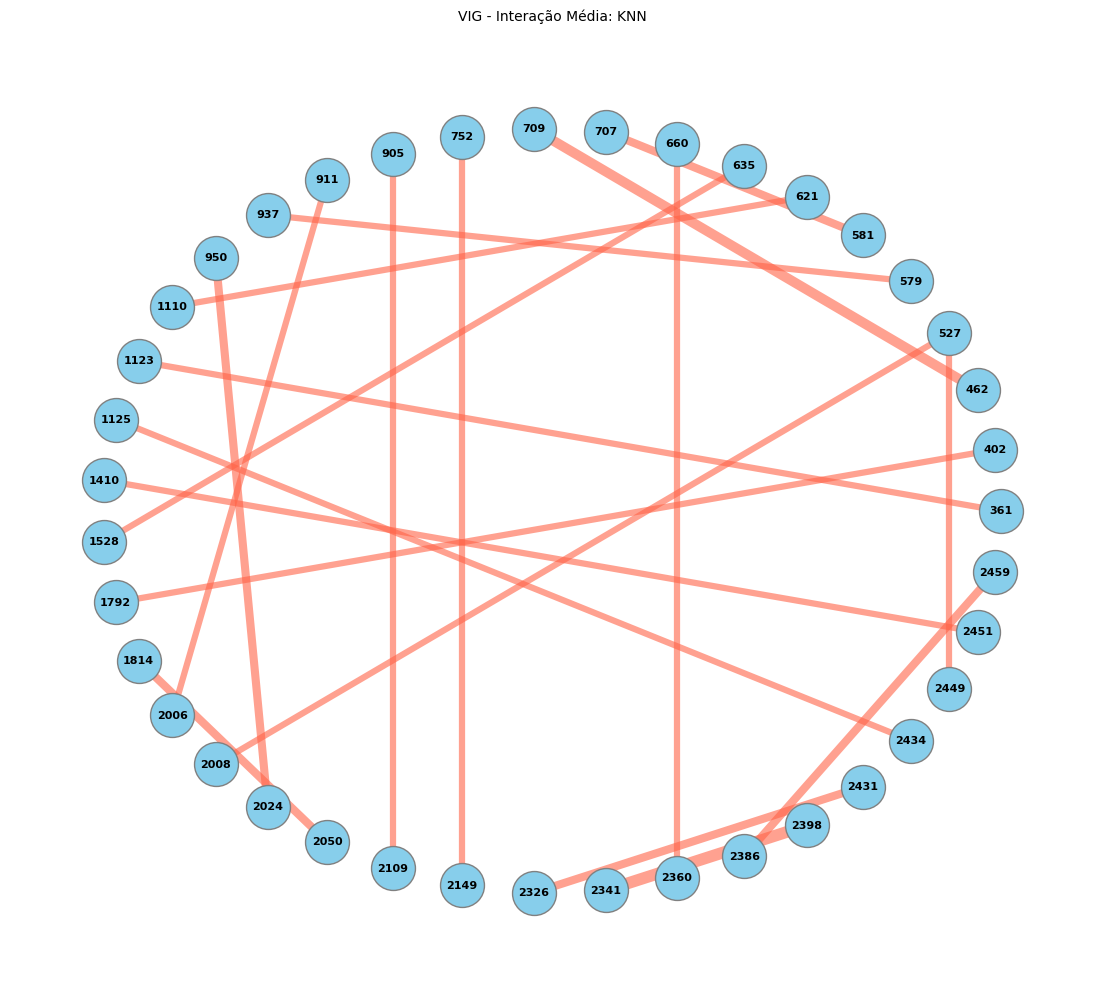

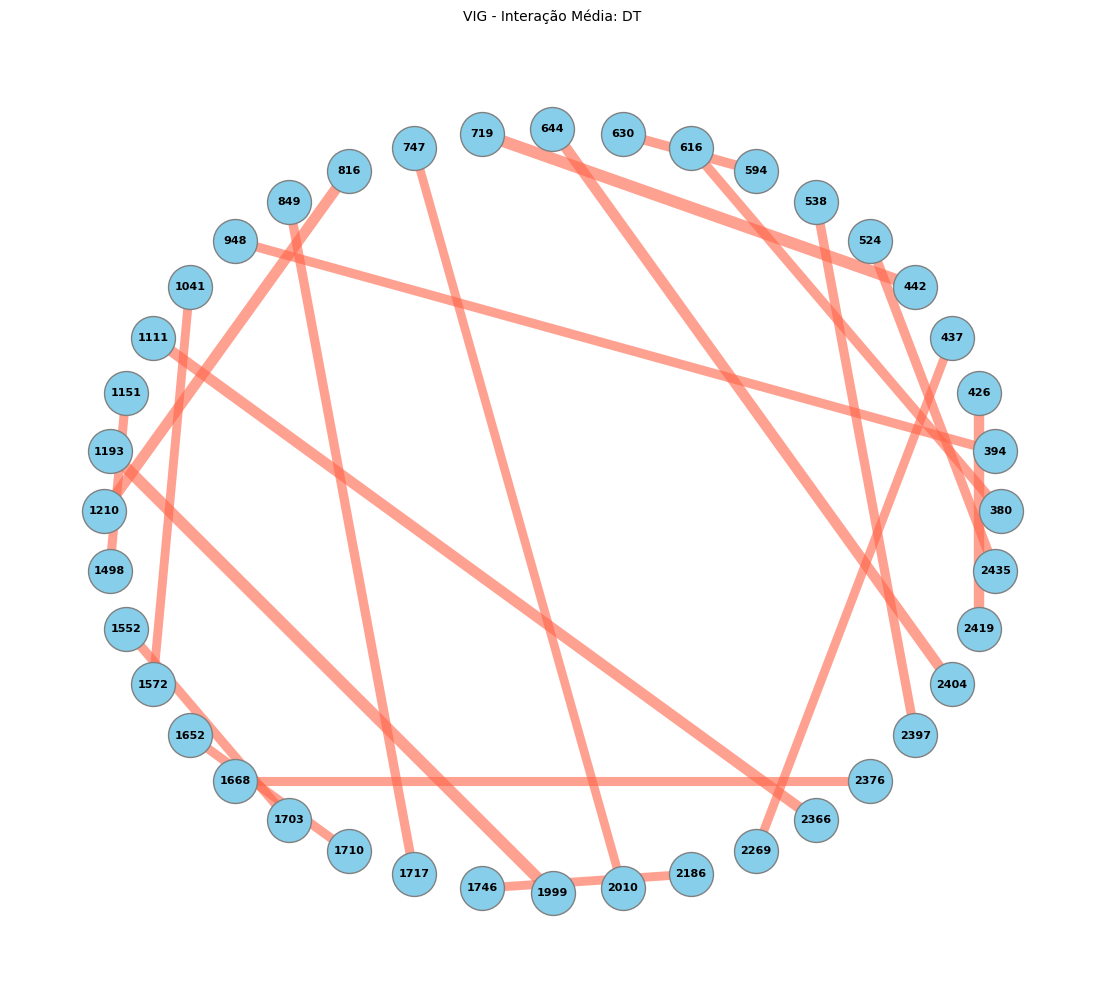

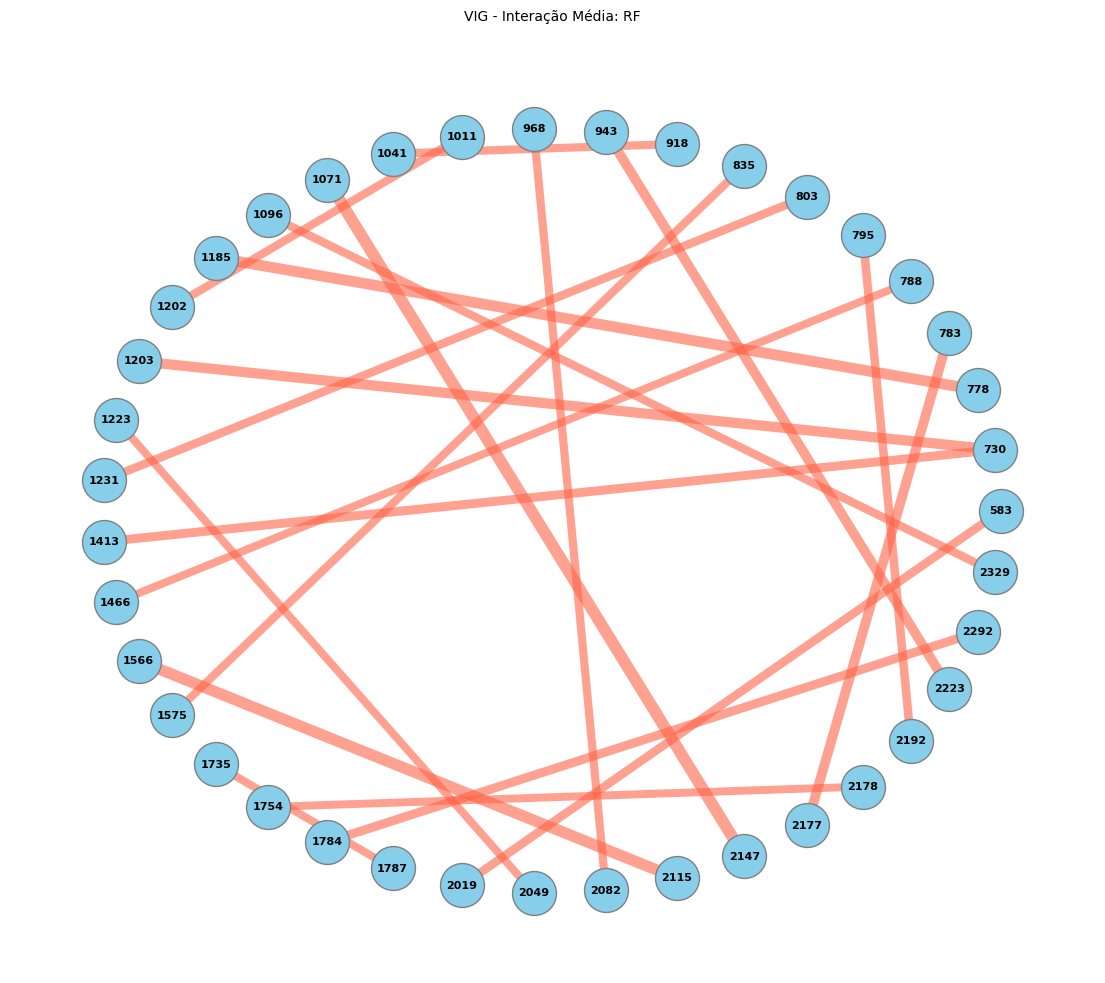

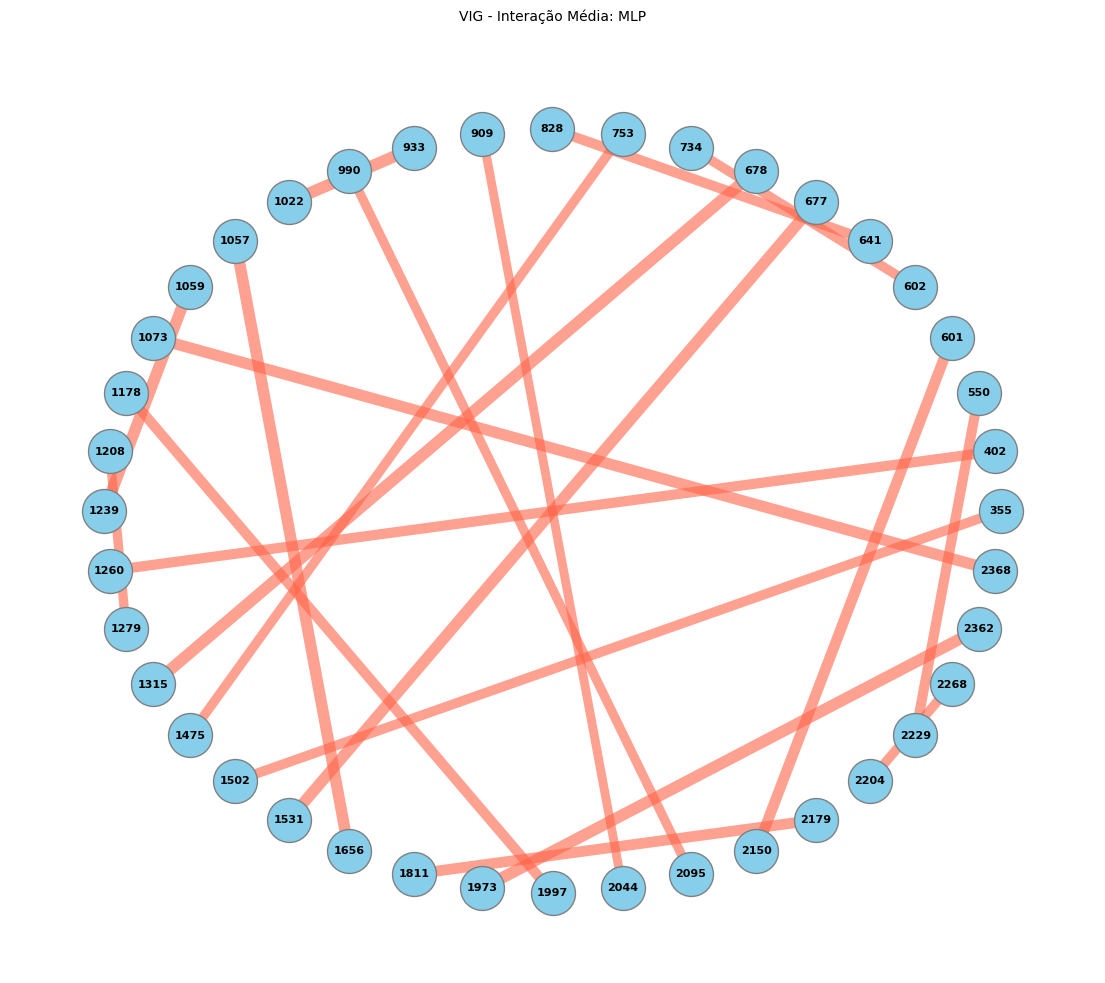

In [15]:
for model, interactions in model_data.items():
    plot_interaction_graph(model, interactions)